# 项目：用线性回归预测房价数据

## 分析目标

此数据分析报告的目的是，基于已有的房屋销售价格，以及有关该房屋的属性，进行线性回归分析，从而利用得到的线性回归模型，能对以下未知售价的房屋根据属性进行价格预测：

面积为6500平方英尺，有4个卧室、2个厕所，总共2层，不位于主路，无客人房，带地下室，有热水器，没有空调，车位数为2，位于城市首选社区，简装修。

## 简介

数据集`house_price.csv`记录了超过五百栋房屋的交易价格，以及房屋的相关属性信息，包括房屋面积、卧室数、厕所数、楼层数、是否位于主路、是否有客房，等等。

`house_price.csv`每列的含义如下：
- price：房屋出售价格
- area：房屋面积，以平方英尺为单位
- bedrooms：卧室数
- bathrooms：厕所数
- stories：楼层数
- mainroad：是否位于主路
   - yes  是
   - no	  否
- guestroom：是否有客房
   - yes  是
   - no	  否
- basement：是否有地下室
   - yes  是
   - no	  否
- hotwaterheating：是否有热水器
   - yes  是
   - no	  否
- airconditioning：是否有空调
   - yes  是
   - no	  否
- parking：车库容量，以车辆数量为单位
- prefarea：是否位于城市首选社区
   - yes  是
   - no	  否
- furnishingstatus：装修状态
   - furnished       精装
   - semi-furnished	 简装
   - unfurnished     毛坯

做数据分析之前，首先导入数据分析所需要的库和原始数据。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

导入原始数据，并将原始数据赋值给变量original_data。

In [2]:
original_data = pd.read_csv('house_price.csv')
original_data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


## 评估数据

评估数据主要分为两个方面，即数据整洁度和干净度。评估整洁度需要看数据是否符合“每行只有一个观察值，每列只有一个变量，每个单元格只有一个数据值”，评估干净度主要看数据有无空缺数据，重复数据，不一致数据，无效及错误数据等。

为了区分评估后的数据和原始数据，我们创建新的变量cleaned_data，并将原始数据original_data复制的副本赋值给它，后面的清洗步骤均在cleaned_data上进行。

In [3]:
cleaned_data = original_data.copy()
cleaned_data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


### 评估数据整齐度

该数据符合整洁数据的“每行是一个观察值，每列是一个变量，每个单元格是一个值”的标准，因此属于整洁数据，不需要进行处理。

### 评估数据干净度

#### 处理空缺值

先调用info方法来对数据内容有个大概了解。

In [4]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


可以得知数据共有545行观察值，没有空缺值，不需要处理缺失数据。

另外mainroad、guestroom、basement、hotwaterheating、airconditioning、prefarea、furnishingstatus这些变量都属于分类数据，我们可以把它们的类型转换为Category。

In [5]:
cleaned_data['mainroad'] = cleaned_data['mainroad'].astype('category')
cleaned_data['guestroom'] = cleaned_data['guestroom'].astype('category')
cleaned_data['basement'] = cleaned_data['basement'].astype('category')
cleaned_data['hotwaterheating'] = cleaned_data['hotwaterheating'].astype('category')
cleaned_data['airconditioning'] = cleaned_data['airconditioning'].astype('category')
cleaned_data['prefarea'] = cleaned_data['prefarea'].astype('category')
cleaned_data['furnishingstatus'] = cleaned_data['furnishingstatus'].astype('category')

In [6]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   price             545 non-null    int64   
 1   area              545 non-null    int64   
 2   bedrooms          545 non-null    int64   
 3   bathrooms         545 non-null    int64   
 4   stories           545 non-null    int64   
 5   mainroad          545 non-null    category
 6   guestroom         545 non-null    category
 7   basement          545 non-null    category
 8   hotwaterheating   545 non-null    category
 9   airconditioning   545 non-null    category
 10  parking           545 non-null    int64   
 11  prefarea          545 non-null    category
 12  furnishingstatus  545 non-null    category
dtypes: category(7), int64(6)
memory usage: 30.3 KB


#### 处理重复数据

根据数据每个变量的含义可以得知，允许出现所有变量都相同的观察值，因此不需要处理重复数据。

#### 处理不一致数据

分类变量中可能存在不一致数据，即存在不同值指代同一目标的情况，因此需要查看这些变量。

In [7]:
cleaned_data['mainroad'].value_counts()

yes    468
no      77
Name: mainroad, dtype: int64

In [8]:
cleaned_data['guestroom'].value_counts()

no     448
yes     97
Name: guestroom, dtype: int64

In [9]:
cleaned_data['basement'].value_counts()

no     354
yes    191
Name: basement, dtype: int64

In [10]:
cleaned_data['hotwaterheating'].value_counts()

no     520
yes     25
Name: hotwaterheating, dtype: int64

In [11]:
cleaned_data['airconditioning'].value_counts()

no     373
yes    172
Name: airconditioning, dtype: int64

In [12]:
cleaned_data['prefarea'].value_counts()

no     417
yes    128
Name: prefarea, dtype: int64

In [13]:
cleaned_data['furnishingstatus'].value_counts()

semi-furnished    227
unfurnished       178
furnished         140
Name: furnishingstatus, dtype: int64

经验证，数据集里没有不一致数据。

#### 处理无效和错误数据

调用describe方法查看数值变量的描述统计概况

In [14]:
cleaned_data.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


从以上信息来看，不存在脱离现实意义的数据。

### 探索数据

在进行数据分析之前，可以使用可视化来探索数值变量的分布情况及房价与各变量之间的关系。

In [15]:
#设置色盘为"pastel"
sns.set_palette('pastel')

#### 房价分布

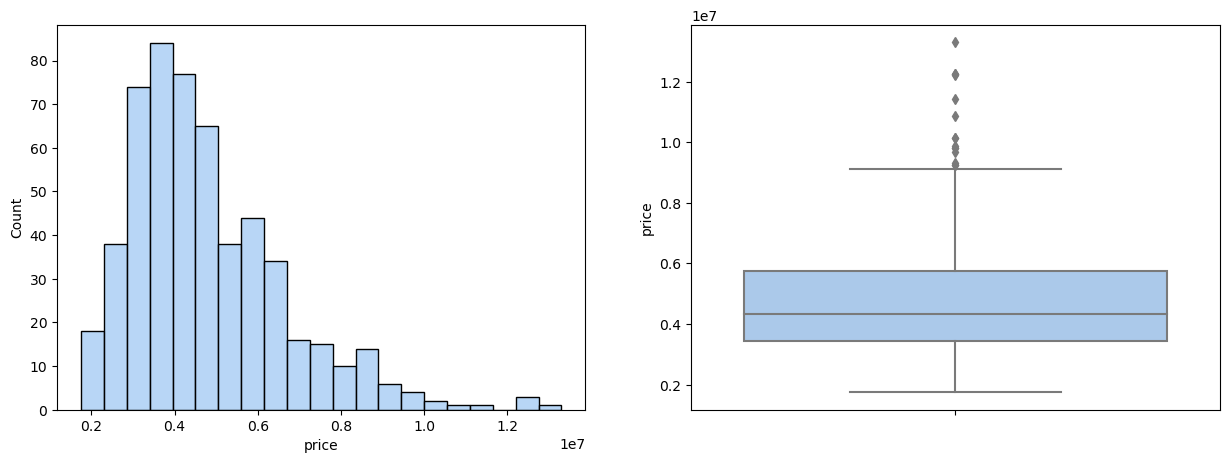

In [16]:
fig, axes = plt.subplots(1, 2, figsize = (15,5))
sns.histplot(cleaned_data, x = 'price', ax = axes[0])
sns.boxplot(data = cleaned_data, y = 'price', ax = axes[1])
plt.show()

可以看出数据集中的房价成右偏态分布，大多数价格中等，有少数价格极高的房价。

#### 房价与面积的关系

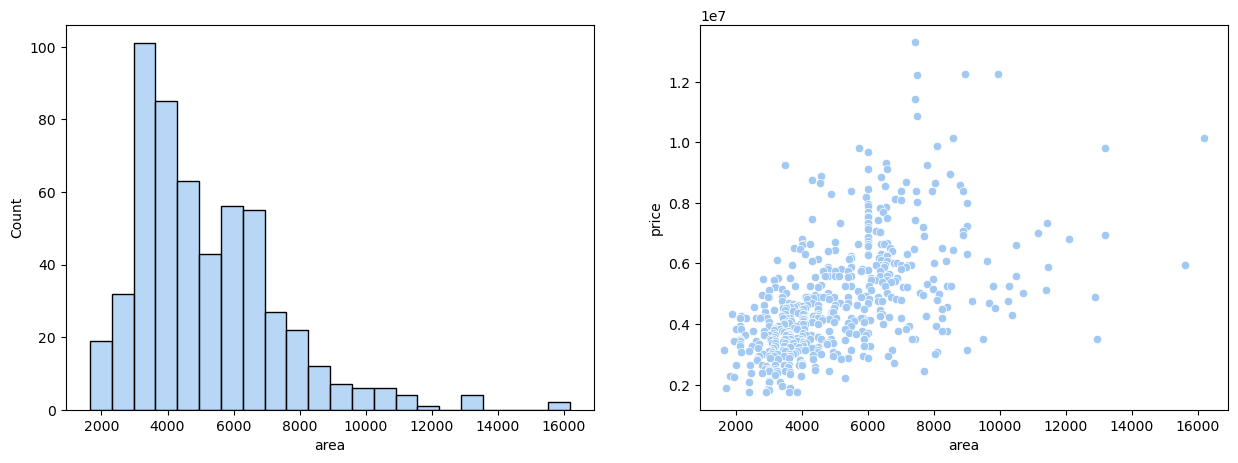

In [17]:
fig, axes = plt.subplots(1,2, figsize = (15,5))
sns.histplot(cleaned_data, x = 'area', ax = axes[0])
sns.scatterplot(data = cleaned_data, x = 'area', y= 'price',ax = axes[1])
plt.show()

从图上可知，数据集里房屋面积呈右偏态分布，大多分布在中等大小，有少数面积极大的房屋。  
从散点图来看基本上房屋面积越大，房价就越大，但房屋面积对房价的影响程度还需要后续具体分析。

#### 卧室数量与房价的关系

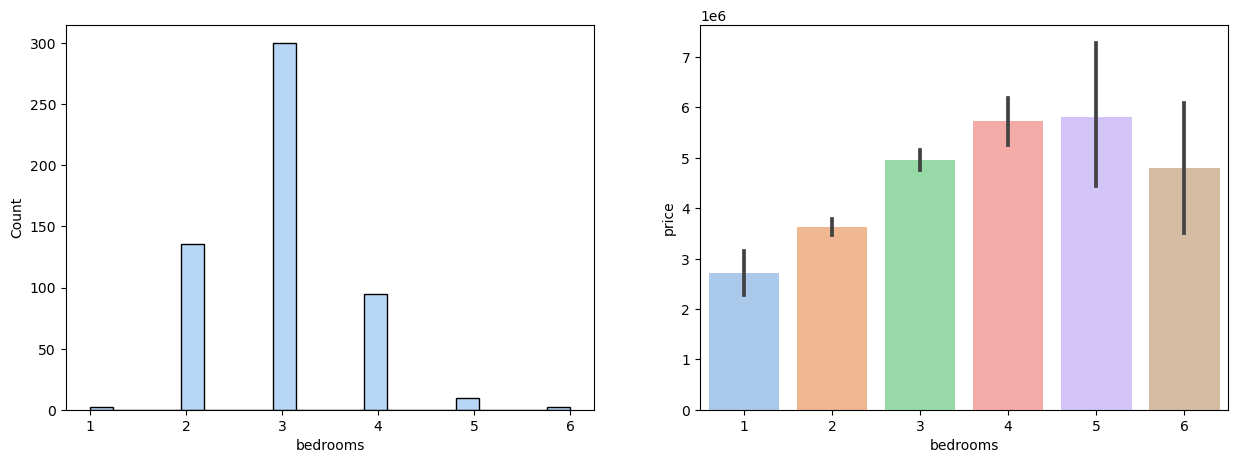

In [18]:
fig, axes = plt.subplots(1,2, figsize = (15,5))
sns.histplot(cleaned_data, x = 'bedrooms', ax = axes[0])
sns.barplot(data = cleaned_data, x = 'bedrooms', y= 'price',ax = axes[1])
plt.show()

从直方图可以看出，房屋的卧室数量大多集中在2，3，4，，卧室数量3各的房屋数量最多。从条形图上来看，卧室数量在5各以内，卧室越多房价越高，卧室大于5个时房价不一定会增高。

#### 盥洗室数量和房价的关系

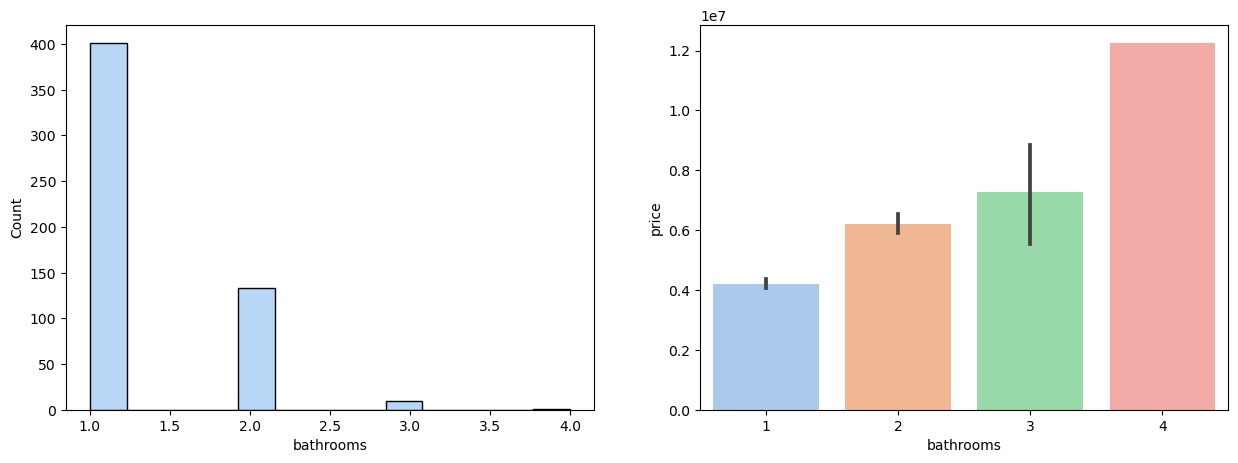

In [19]:
fig, axes = plt.subplots(1,2, figsize = (15,5))
sns.histplot(cleaned_data, x = 'bathrooms', ax = axes[0])
sns.barplot(data = cleaned_data, x = 'bathrooms', y= 'price',ax = axes[1])
plt.show()

从直方图可知，房屋的盥洗室数量绝大多数都是1个，数量为2个是其次。  
从条形图可知，随着盥洗室数量越多，房屋的平均房价越高。

#### 楼层数与房价的关系

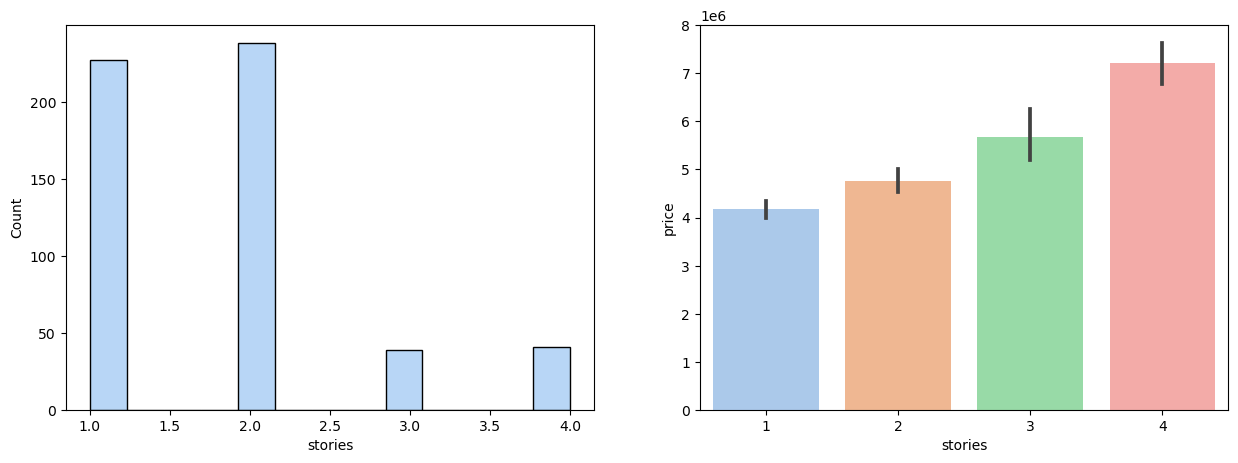

In [20]:
fig, axes = plt.subplots(1,2, figsize = (15,5))
sns.histplot(cleaned_data, x = 'stories', ax = axes[0])
sns.barplot(data = cleaned_data, x = 'stories', y= 'price',ax = axes[1])
plt.show()

从直方图可以看出，一层或两层楼的房屋分布数量最多。  
从楼层数与平均房价的条形图来看，房价随着楼层数量增加而增加。

#### 车库数量与房价的关系

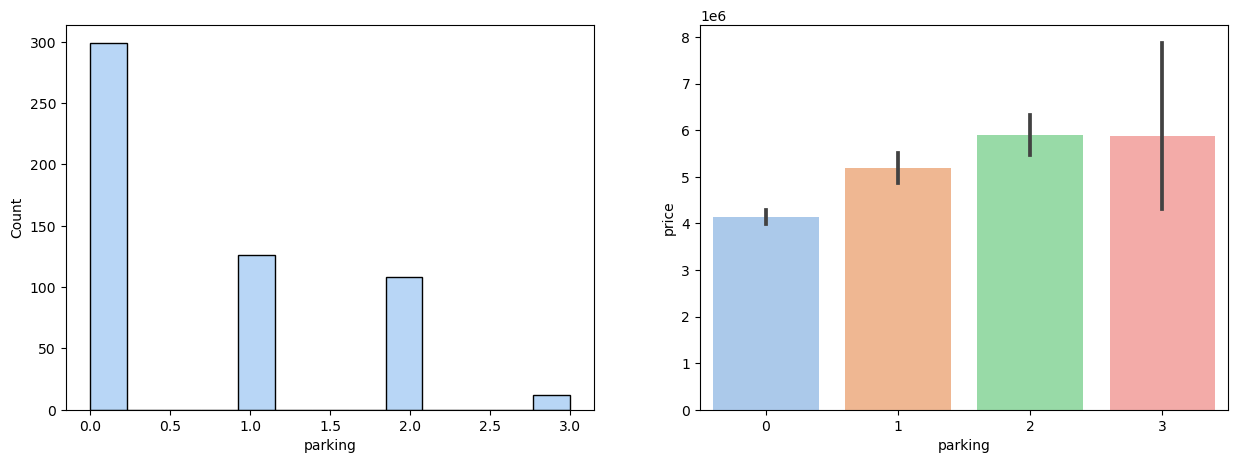

In [21]:
fig, axes = plt.subplots(1,2, figsize = (15,5))
sns.histplot(cleaned_data, x = 'parking', ax = axes[0])
sns.barplot(data = cleaned_data, x = 'parking', y= 'price',ax = axes[1])
plt.show()

从直方图可以看出，不带车库的房子最多，车库数为2，3的其次。  
从条形图来看，车库数如果在3个以内，那么车库越多房价就越高，但车库如果超过3个，那么房价不一定会变高。

#### 是否位于主路与房价的关系

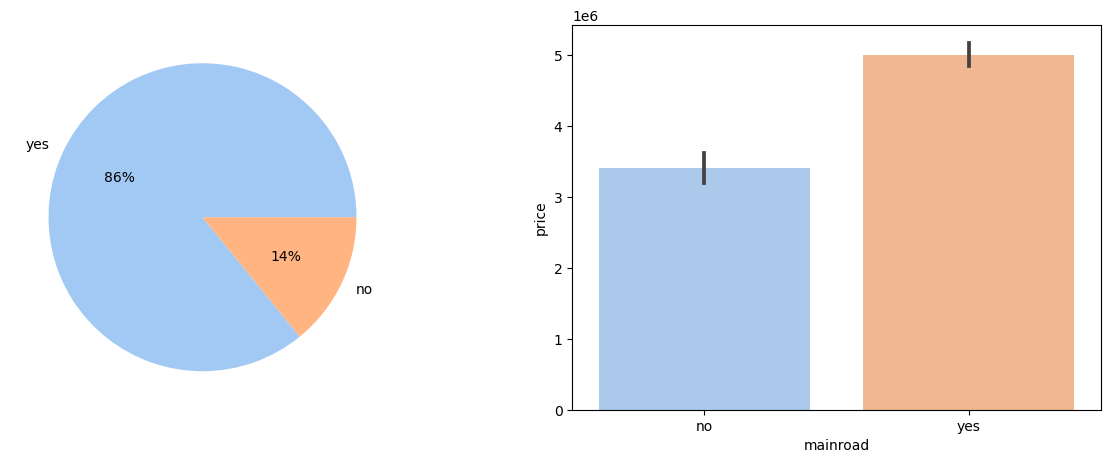

In [22]:
fig, axes = plt.subplots(1,2, figsize = (15,5))
mainroad_count = cleaned_data['mainroad'].value_counts()
mainroad_label = mainroad_count.index
axes[0].pie(mainroad_count, labels = mainroad_label, autopct = '%.0f%%')
sns.barplot(data = cleaned_data, x = 'mainroad', y= 'price',ax = axes[1])
plt.show()

从饼图可以看出，数据集里大多数房屋都不位于主路段。  
从条形图来看，位于主路段的房屋平均价格高于非主路段的房屋平均价格。

#### 是否有客房与房价的关系

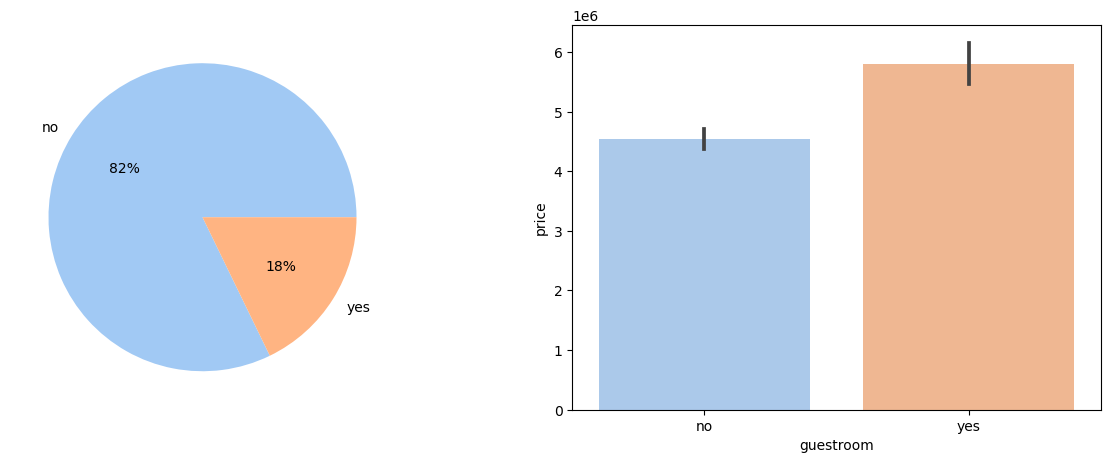

In [23]:
fig, axes = plt.subplots(1,2, figsize = (15,5))
guestroom_count = cleaned_data['guestroom'].value_counts()
guestroom_label = guestroom_count.index
axes[0].pie(guestroom_count, labels = guestroom_label, autopct = '%.0f%%')
sns.barplot(data = cleaned_data, x = 'guestroom', y= 'price',ax = axes[1])
plt.show()

从饼图可以看出，数据集里大多数房子都不带有客房。  
从条形图可以看出，带有客房的房屋价格高于不带有客房的房屋价格。

#### 带有地下室与房价的关系

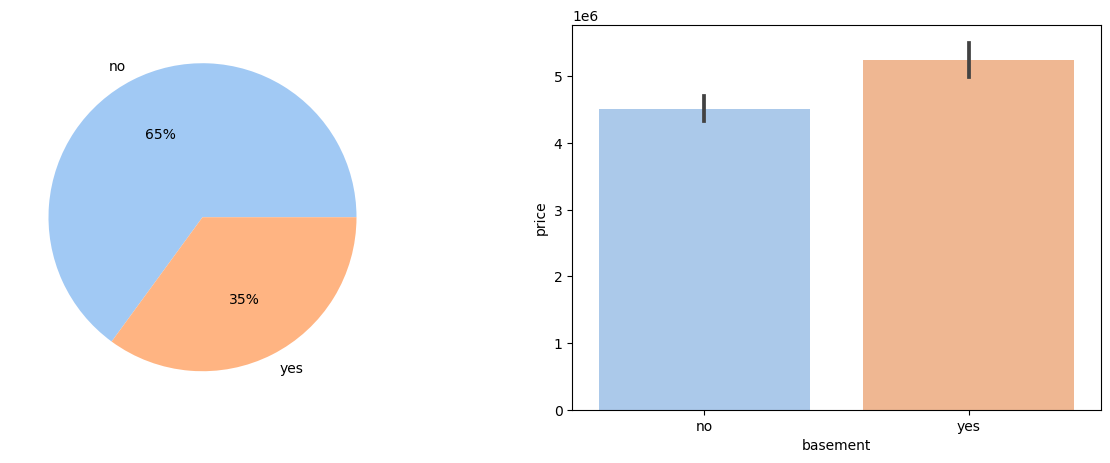

In [24]:
fig, axes = plt.subplots(1,2, figsize = (15,5))
basement_count = cleaned_data['basement'].value_counts()
basement_label = basement_count.index
axes[0].pie(basement_count, labels = basement_label, autopct = '%.0f%%')
sns.barplot(data = cleaned_data, x = 'basement', y= 'price',ax = axes[1])
plt.show()

从饼图来看，数据集里带有大多数房子不带地下室。  
从条形图看，带有地下室的房屋平均价格大于不带地下室的房屋。

#### 带有热水器与房价的关系

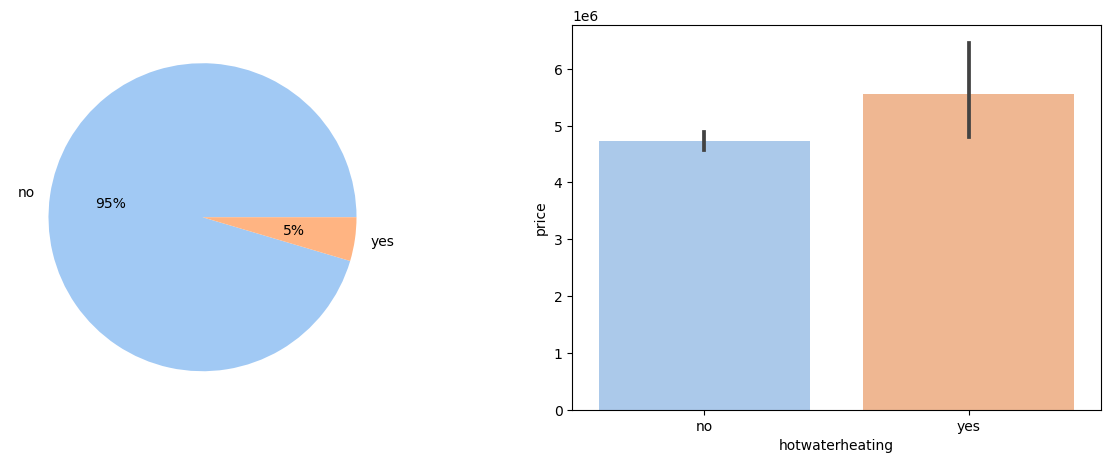

In [25]:
fig, axes = plt.subplots(1,2, figsize = (15,5))
hotwaterheating_count = cleaned_data['hotwaterheating'].value_counts()
hotwaterheating_label = hotwaterheating_count.index
axes[0].pie(hotwaterheating_count, labels = hotwaterheating_label, autopct = '%.0f%%')
sns.barplot(data = cleaned_data, x = 'hotwaterheating', y= 'price',ax = axes[1])
plt.show()

从饼图来看，数据集里绝大多数房屋没有热水器。  
从条形图看，带有热水器的房屋价格高于不带热水器的房屋价格。

#### 安装空调与房价的关系

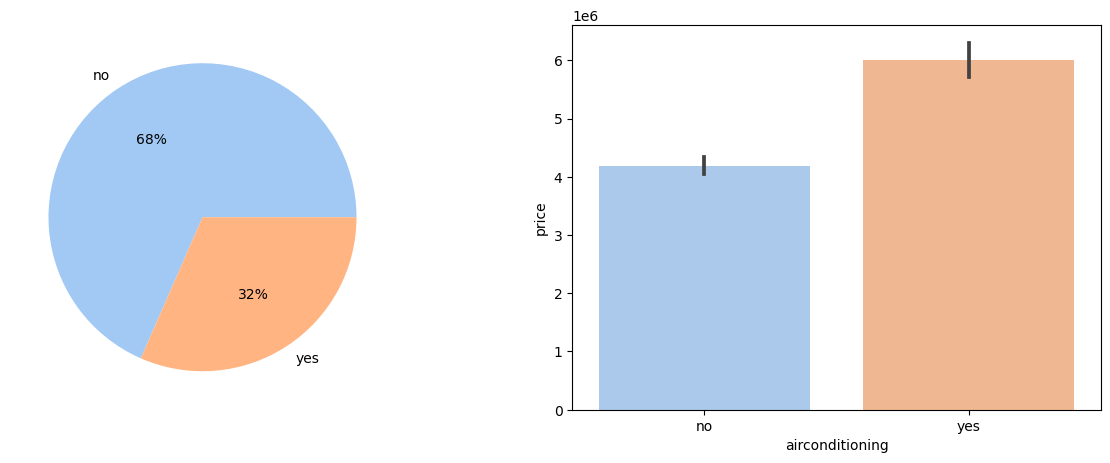

In [26]:
fig, axes = plt.subplots(1,2, figsize = (15,5))
airconditioning_count = cleaned_data['airconditioning'].value_counts()
airconditioning_label = airconditioning_count.index
axes[0].pie(airconditioning_count, labels = airconditioning_label, autopct = '%.0f%%')
sns.barplot(data = cleaned_data, x = 'airconditioning', y= 'price',ax = axes[1])
plt.show()

从饼图看，数据集里大多数房子都没有安装空调。  
从条形图来看，带有空调的房子价格高于不带有空调的房子。

#### 是否位于首选社区与房价的关系

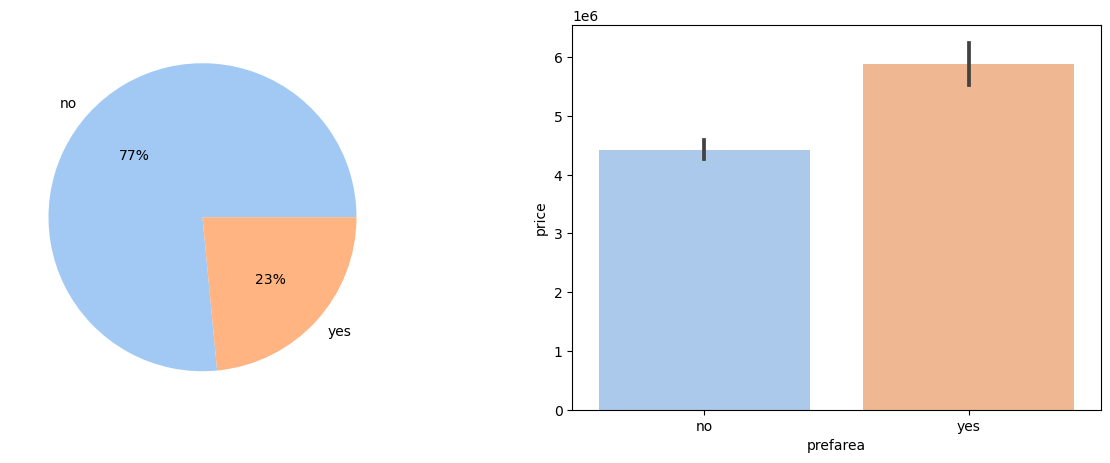

In [27]:
fig, axes = plt.subplots(1,2, figsize = (15,5))
prefarea_count = cleaned_data['prefarea'].value_counts()
prefarea_label = prefarea_count.index
axes[0].pie(prefarea_count, labels = prefarea_label, autopct = '%.0f%%')
sns.barplot(data = cleaned_data, x = 'prefarea', y= 'price',ax = axes[1])
plt.show()

从饼图来看，数据集里多数房子不位于主路段。  
从条形图看，位于主路段的房价平均值高于不位于主路段的房子。

#### 装修状态与房屋价格的关系

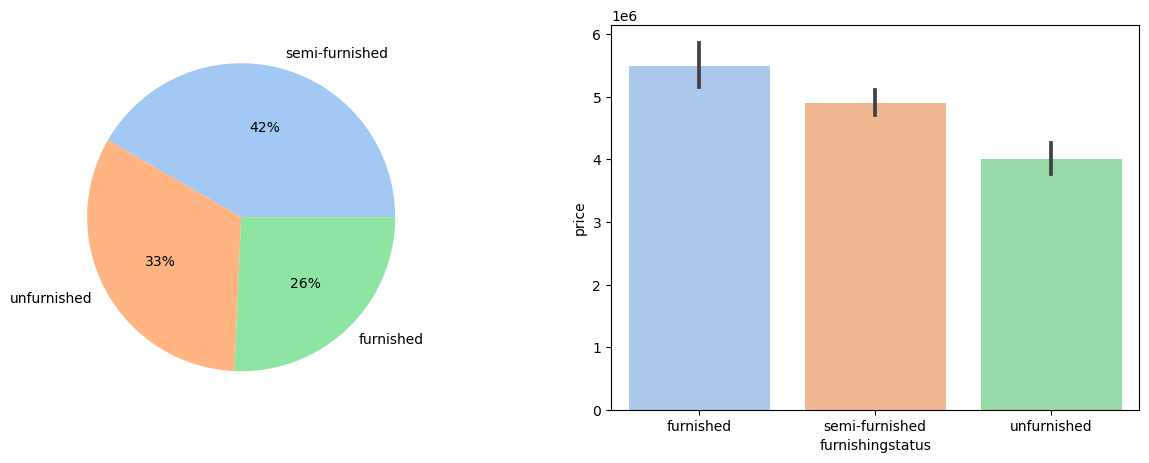

In [28]:
fig, axes = plt.subplots(1,2, figsize = (15,5))
furnishingstatus_count = cleaned_data['furnishingstatus'].value_counts()
furnishingstatus_label = furnishingstatus_count.index
axes[0].pie(furnishingstatus_count, labels = furnishingstatus_label, autopct = '%.0f%%')
sns.barplot(data = cleaned_data, x = 'furnishingstatus', y= 'price',ax = axes[1])
plt.show()

从饼图来看，数据集里简装的房子数量最多，毛坯房其次，精装房屋数量占比最少。  
从条形图看，精装房屋平均价格最高，简装房屋其次，毛坯房平均房价最低。

### 分析数据

我们将根据数据集cleaned_data，进行线性回归分析，得到一个自变量为房屋各属性，因变量为房屋价格的线性回归模型，从而可以根据题目中的房屋属性预测该房屋的价格。

引入线性回归分析所需要的模块

In [29]:
import statsmodels.api as sm

在进行数据分析前，需要创建一个新的变量lr_data，并将清洗后的数据cleaned_data复制的副本赋值给它，因为在做线性回归分析前，还需要对数据做一些准备，这些操作都可以在lr_data上进行。

In [30]:
lr_data = cleaned_data.copy()
lr_data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


#### 引入虚拟变量

guestroom、basement、hotwaterheating、airconditioning、prefarea、furnishingstatus这些分类变量需要替换为虚拟变量，用1和0表示是否属于该分类。

In [31]:
lr_data = pd.get_dummies(lr_data, columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus'], dtype = int, drop_first = True)
lr_data

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2,1,0,1,0,0,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,0,1,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


#### 划分线性回归模型的因变量和自变量

In [32]:
y = lr_data['price']
x = lr_data.drop('price', axis = 1)

#### 计算x各变量之间的相关系数r

In [33]:
r = x.corr().abs()
r

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
area,1.000000,0.151858,0.193820,0.083996,0.352980,0.288874,0.140297,0.047417,0.009229,0.222393,0.234779,0.006156,0.142278
bedrooms,0.151858,1.000000,0.373930,0.408564,0.139270,0.012033,0.080549,0.097312,0.046049,0.160603,0.079023,0.050040,0.126252
bathrooms,0.193820,0.373930,1.000000,0.326165,0.177496,0.042398,0.126469,0.102106,0.067159,0.186915,0.063472,0.029834,0.132107
stories,0.083996,0.408564,0.326165,1.000000,0.045547,0.121706,0.043538,0.172394,0.018847,0.293602,0.044425,0.003648,0.082972
parking,0.352980,0.139270,0.177496,0.045547,1.000000,0.204433,0.037466,0.051497,0.067864,0.159173,0.091627,0.041327,0.165705
mainroad_yes,0.288874,0.012033,0.042398,0.121706,0.204433,1.000000,0.092337,0.044002,0.011781,0.105423,0.199876,0.011450,0.133123
guestroom_yes,0.140297,0.080549,0.126469,0.043538,0.037466,0.092337,1.000000,0.372066,0.010308,0.138179,0.160897,0.005821,0.099023
basement_yes,0.047417,0.097312,0.102106,0.172394,0.051497,0.044002,0.372066,1.000000,0.004385,0.047341,0.228083,0.050284,0.117935
hotwaterheating_yes,0.009229,0.046049,0.067159,0.018847,0.067864,0.011781,0.010308,0.004385,1.000000,0.130023,0.059411,0.063819,0.059194
airconditioning_yes,0.222393,0.160603,0.186915,0.293602,0.159173,0.105423,0.138179,0.047341,0.130023,1.000000,0.117382,0.053179,0.094086


用热力图来表示各变量之间的相关系数，这样能更直观的观察到相关系数的大小。

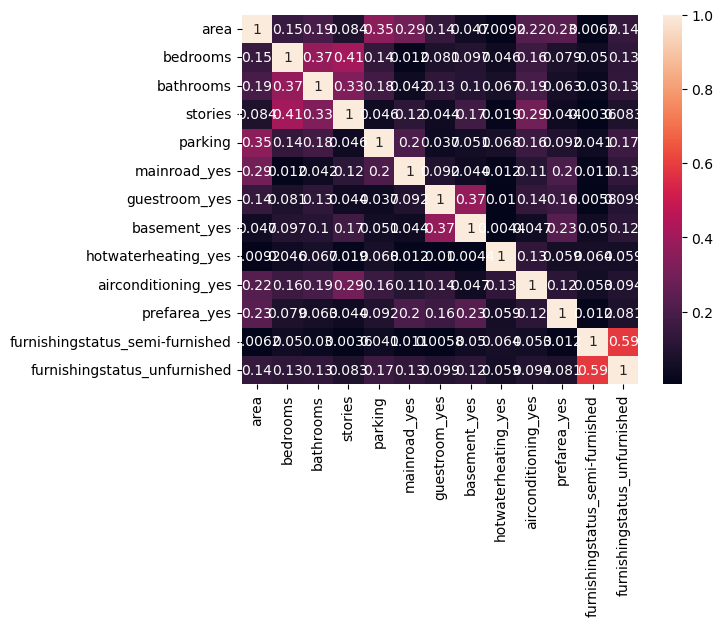

In [34]:
sns.heatmap(r, annot = True)
plt.show()

当自变量之间的相关系数绝对值大于0.8，会导致严重共线性问题，所以我们在检查共线性问题时，要找出相关系数绝对值大于0.8的值。而从以上输出结果看，不同变量之间的相关系数绝对值都小于0.8。

#### 给线性回归模型加入截距

In [35]:
x = sm.add_constant(x)
x

,const,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1.0,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,1.0,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,1.0,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,1.0,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,1.0,7420,4,1,2,2,1,1,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1.0,3000,2,1,1,2,1,0,1,0,0,0,0,1
541,1.0,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1.0,3620,2,1,1,0,1,0,0,0,0,0,0,1
543,1.0,2910,3,1,1,0,0,0,0,0,0,0,0,0


#### 得到线性回归模型

调用OLS方法，利用最小二乘法得到线性回归模型的参数。

In [36]:
#建立线性回归模型
model = sm.OLS(y, x)
#对数据进行拟合
result = sm.OLS(y, x).fit()

In [37]:
#调用summary方法，获得汇总信息
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.674
Method:                 Least Squares   F-statistic:                     87.52
Date:                Wed, 13 Aug 2025   Prob (F-statistic):          9.07e-123
Time:                        18:48:52   Log-Likelihood:                -8331.5
No. Observations:                 545   AIC:                         1.669e+04
Df Residuals:                     531   BIC:                         1.675e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===================================================================================================
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                            4.277e+04   2.64e+05      0.162      0.872   -4.76e+05    5.62e+05
area                              244.1394     24.289     10.052      0.000     196.425     291.853
bedrooms                         1.148e+05   7.26e+04      1.581      0.114   -2.78e+04    2.57e+05
bathrooms                        9.877e+05   1.03e+05      9.555      0.000    7.85e+05    1.19e+06
stories                          4.508e+05   6.42e+04      7.026      0.000    3.25e+05    5.77e+05
parking                          2.771e+05   5.85e+04      4.735      0.000    1.62e+05    3.92e+05
mainroad_yes                     4.213e+05   1.42e+05      2.962      0.003    1.42e+05    7.01e+05
guestroom_yes                    3.005e+05   1.32e+05      2.282      0.023    4.18e+04    5.59e+05
basement_yes                     3.501e+05    1.1e+05      3.175      0.002    1.33e+05    5.67e+05
hotwaterheating_yes              8.554e+05   2.23e+05      3.833      0.000    4.17e+05    1.29e+06
airconditioning_yes               8.65e+05   1.08e+05      7.983      0.000    6.52e+05    1.08e+06
prefarea_yes                     6.515e+05   1.16e+05      5.632      0.000    4.24e+05    8.79e+05
furnishingstatus_semi-furnished -4.634e+04   1.17e+05     -0.398      0.691   -2.75e+05    1.83e+05
furnishingstatus_unfurnished    -4.112e+05   1.26e+05     -3.258      0.001   -6.59e+05   -1.63e+05
==============================================================================
Omnibus:                       97.909   Durbin-Watson:                   1.209
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              258.281
Skew:                           0.895   Prob(JB):                     8.22e-57
Kurtosis:                       5.859   Cond. No.                     3.49e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.49e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

当我们把显著水平设置在0.05时，从以上结果来看，以下自变量的P值大于显著水平，模型认为对房屋价格没有显著影响：bedrooms（卧室数）、furnishingstatus_semi-furnished（是否简装修），此外常数（截距）的P值大于显著水平，也说明对房屋价格没有显著影响。因此需要把这些变量移除，重新建立线性回归模型。

In [38]:
x = x.drop(['bedrooms','furnishingstatus_semi-furnished','const'], axis = 1)
x

,area,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_unfurnished
0,7420,2,3,2,1,0,0,0,1,1,0
1,8960,4,4,3,1,0,0,0,1,0,0
2,9960,2,2,2,1,0,1,0,0,1,0
3,7500,2,2,3,1,0,1,0,1,1,0
4,7420,1,2,2,1,1,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
540,3000,1,1,2,1,0,1,0,0,0,1
541,2400,1,1,0,0,0,0,0,0,0,0
542,3620,1,1,0,1,0,0,0,0,0,1
543,2910,1,1,0,0,0,0,0,0,0,0


In [39]:
result = sm.OLS(y,x).fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  price   R-squared (uncentered):                   0.957
Model:                            OLS   Adj. R-squared (uncentered):              0.956
Method:                 Least Squares   F-statistic:                              1088.
Date:                Wed, 13 Aug 2025   Prob (F-statistic):                        0.00
Time:                        18:48:52   Log-Likelihood:                         -8333.5
No. Observations:                 545   AIC:                                  1.669e+04
Df Residuals:                     534   BIC:                                  1.674e+04
Df Model:                          11                                                  
Covariance Type:            nonrobust                                                  
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
area                           257.5854     22.577     11.409      0.000     213.234     301.936
bathrooms                     1.071e+06   9.27e+04     11.553      0.000    8.89e+05    1.25e+06
stories                       5.084e+05   5.71e+04      8.898      0.000    3.96e+05    6.21e+05
parking                       2.793e+05   5.83e+04      4.794      0.000    1.65e+05    3.94e+05
mainroad_yes                  4.672e+05   1.27e+05      3.679      0.000    2.18e+05    7.17e+05
guestroom_yes                 2.851e+05   1.31e+05      2.172      0.030    2.72e+04    5.43e+05
basement_yes                  4.016e+05   1.07e+05      3.765      0.000    1.92e+05    6.11e+05
hotwaterheating_yes           8.668e+05   2.23e+05      3.884      0.000    4.28e+05    1.31e+06
airconditioning_yes           8.543e+05   1.07e+05      7.952      0.000    6.43e+05    1.07e+06
prefarea_yes                  6.443e+05   1.15e+05      5.594      0.000    4.18e+05    8.71e+05
furnishingstatus_unfurnished -3.493e+05   9.49e+04     -3.679      0.000   -5.36e+05   -1.63e+05
==============================================================================
Omnibus:                       94.840   Durbin-Watson:                   1.262
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              251.889
Skew:                           0.865   Prob(JB):                     2.01e-55
Kurtosis:                       5.845   Cond. No.                     2.74e+04
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 2.74e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

可以看到把P值较大的自变量移除后，R方的值从0.682增长到了0.957，提高了模型对现有数据的拟合度。

另外从模型中各自变量的系数来看，以下变量增加或存在会对因变量（房屋价格）有显著提升：area、bathrooms、stories、parking、mainroad_yes、guestroom_yes、basement_yes、hotwaterheating_yes、airconditioning_yes、prefarea_yes。  
以下自变量的存在会对因变量（房屋价格）有显著降低：furnishingstatus_unfurnished。

#### 预测房屋价格

题目要求根据房屋属性对以下房屋价格进行预测：  
面积为6500平方英尺，有4个卧室、2个厕所，总共2层，不位于主路，无客人房，带地下室，有热水器，没有空调，车位数为2，位于城市首选社区，简装修。

In [40]:
new_observation = pd.DataFrame({'area':[6500], 'bedrooms':[4], 'bathrooms':[2], 'stories':[2], 'mainroad':['no'],
                                'guestroom':['no'], 'basement':['yes'], 'hotwaterheating':['yes'], 
                               'airconditioning':['no'], 'parking':[2], 'prefarea':['yes'], 'furnishingstatus':['semi-furnished']}
) 
new_observation

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,6500,4,2,2,no,no,yes,yes,no,2,yes,semi-furnished


需要将分类变量的数据类型通过Categorical方法转化为Category，并让程序知道每个分类变量的所有分类，因为需要预测的数据包含的分类可能不全，需要确保引入虚拟变量的时候不漏掉某个分类。

In [41]:
new_observation['mainroad'] = pd.Categorical(new_observation['mainroad'], categories = ['no', 'yes'])
new_observation['guestroom'] = pd.Categorical(new_observation['guestroom'], categories = ['no', 'yes'])
new_observation['basement'] = pd.Categorical(new_observation['basement'], categories = ['no', 'yes'])
new_observation['hotwaterheating'] = pd.Categorical(new_observation['hotwaterheating'], categories = ['no', 'yes'])
new_observation['airconditioning'] = pd.Categorical(new_observation['airconditioning'], categories = ['no', 'yes'])
new_observation['prefarea'] = pd.Categorical(new_observation['prefarea'], categories = ['no', 'yes'])
new_observation['furnishingstatus'] = pd.Categorical(new_observation['furnishingstatus'], categories = ['furnished', 'semi-furnished', 'unfurnished'])

In [42]:
new_observation = pd.get_dummies(new_observation, columns = ['mainroad','guestroom','basement','hotwaterheating',
                                'airconditioning','prefarea','furnishingstatus'], dtype = int, drop_first = True )
new_observation

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,6500,4,2,2,2,0,0,1,1,0,1,1,0


In [44]:
new_observation = new_observation.drop(['bedrooms','furnishingstatus_semi-furnished'], axis = 1)

由前面建立的线性回归模型得知，模型不需要添加截距，因此需要预测的房屋属性数据也不需要加入截距。

以上就得到与线性回归模型自变量相符合的预测数据，接下来可以调用线性回归模型的predict方法预测房屋价格。

In [45]:
result.predict(new_observation)

0    7.303754e+06
dtype: float64

房屋预测价格为：7303754